In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [2]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gpt-oss",
    temperature=.8,
    max_tokens=1000,
    max_retries=3
)

result = model.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [3]:
result

AIMessage(content='### Where to Spot Orcas (Killer Whales) in the United States  \n(Updated 2026)\n\n| Region | Best Time of Year | Why It’s a Top Spot | Tips for the Experience |\n|--------|-------------------|---------------------|------------------------|\n| **San Juan Islands, Washington** | **January – March** (Pacific Northwest winter) | •\u202fHighly concentrated “resident” orcas (the “Killer‑Whale” pod).<br>•\u202fUp to 90% of sightings in the area during peak season.<br>•\u202fClear, calm waters and well‑established tour operators. | •\u202fBook a guided whale‑watching tour (e.g., OrcaQuest, Whale Watch San Juan).<br>•\u202fWear layered clothing; it can be chilly. |\n| **Catalina Island, California** | **June – October** (Southern California summer) | •\u202fBoth “resident” and “transient” orcas frequent the channel.<br>•\u202fGood chance of spotting large pods. | •\u202fTake a boat trip from Avalon or Long Beach.<br>•\u202fAvoid crowded days; early morning or late afternoon g

In [4]:
result.pretty_print()

================================== Ai Message ==================================

### Where to Spot Orcas (Killer Whales) in the United States  
(Updated 2026)

| Region | Best Time of Year | Why It’s a Top Spot | Tips for the Experience |
|--------|-------------------|---------------------|------------------------|
| **San Juan Islands, Washington** | **January – March** (Pacific Northwest winter) | • Highly concentrated “resident” orcas (the “Killer‑Whale” pod).<br>• Up to 90% of sightings in the area during peak season.<br>• Clear, calm waters and well‑established tour operators. | • Book a guided whale‑watching tour (e.g., OrcaQuest, Whale Watch San Juan).<br>• Wear layered clothing; it can be chilly. |
| **Catalina Island, California** | **June – October** (Southern California summer) | • Both “resident” and “transient” orcas frequent the channel.<br>• Good chance of spotting large pods. | • Take a boat trip from Avalon or Long Beach.<br>• Avoid crowded days; early morning or late

In [6]:
result.response_metadata

{'model': 'gpt-oss',
 'created_at': '2026-04-20T08:00:48.6784509Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 11865315600,
 'load_duration': 4524512500,
 'prompt_eval_count': 123,
 'prompt_eval_duration': 74525900,
 'eval_count': 1054,
 'eval_duration': 6795903800,
 'logprobs': None,
 'model_name': 'gpt-oss',
 'model_provider': 'ollama'}

# Tools

In [7]:
def multiply(a: int, b:int)->int:
    """
    Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

model_with_tools = model.bind_tools([multiply])

In [8]:
tool_call = model_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by3?", name="Najeeb")])

In [9]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '5a75c268-fde4-462e-b355-e9c046999ee3',
  'type': 'tool_call'}]

In [12]:
from typing import TypedDict
from langchain_core.messages import AnyMessage

class MessageState(TypedDict):
    messages: list[AnyMessage]

In [13]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [14]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    pass

In [15]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='3931b6dc-2d4c-49fc-97b7-cf408fb62a4a', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='347f1636-fcec-4ee8-ac61-27b2e3db69ba'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='06e2d8fb-15a2-45df-acf8-b7fe3cea6de3', tool_calls=[], invalid_tool_calls=[])]

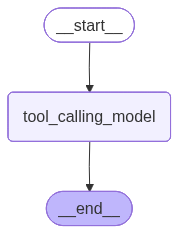

In [16]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def tool_calling_model(state: MessagesState):
    return {"messages": [model_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_model", tool_calling_model)
builder.add_edge(START, "tool_calling_model")
builder.add_edge("tool_calling_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I help you today?


In [18]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (15005a4f-bb69-4bd5-a72c-0eb5fc6187fd)
 Call ID: 15005a4f-bb69-4bd5-a72c-0eb5fc6187fd
  Args:
    a: 2
    b: 3


# Router

In [20]:
llm = model
llm_with_tools = llm.bind_tools([multiply])

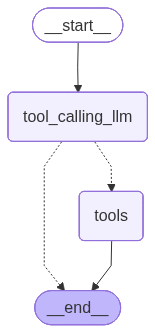

In [21]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
help(tools_condition)

Help on function tools_condition in module langgraph.prebuilt.tool_node:

tools_condition(state: 'list[AnyMessage] | dict[str, Any] | BaseModel', messages_key: 'str' = 'messages') -> "Literal['tools', '__end__']"
    Conditional routing function for tool-calling workflows.

    This utility function implements the standard conditional logic for ReAct-style
    agents: if the last `AIMessage` contains tool calls, route to the tool execution
    node; otherwise, end the workflow. This pattern is fundamental to most tool-calling
    agent architectures.

    The function handles multiple state formats commonly used in LangGraph applications,
    making it flexible for different graph designs while maintaining consistent behavior.

    Args:
        state: The current graph state to examine for tool calls. Supported formats:
            - Dictionary containing a messages key (for `StateGraph`)
            - `BaseModel` instance with a messages attribute
        messages_key: The key or att

In [26]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (11aff6f7-c66a-4a9c-8123-1a0e4c4a320d)
 Call ID: 11aff6f7-c66a-4a9c-8123-1a0e4c4a320d
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4
